In [24]:
import kagglehub
path = kagglehub.dataset_download("tongpython/cat-and-dog")

Using Colab cache for faster access to the 'cat-and-dog' dataset.


In [25]:
print("Dataset path:", path)

Dataset path: /kaggle/input/cat-and-dog


In [26]:
import shutil
import os

# Copy from cache to /content/ (visible in Files panel)
shutil.copytree(path, "/content/cat-and-dog")

print("Done! Refresh the Files panel now.")

FileExistsError: [Errno 17] File exists: '/content/cat-and-dog'

In [27]:
!pip install tensorflow

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [29]:
train_ds=keras.utils.image_dataset_from_directory(
    directory = "/content/cat-and-dog/training_set/training_set",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256,256)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory = "/content/cat-and-dog/test_set/test_set",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (256,256)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [30]:
#Normalize
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)


In [33]:
from flax.nnx import Dropout
model =Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(64,activation='relu'))


model.add(Dense(1,activation='sigmoid'))


In [34]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.5810 - loss: 1.7180 - val_accuracy: 0.5699 - val_loss: 0.8551
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.6616 - loss: 0.6859 - val_accuracy: 0.6139 - val_loss: 0.7286
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.7072 - loss: 0.5900 - val_accuracy: 0.6856 - val_loss: 0.6350
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.7626 - loss: 0.4983 - val_accuracy: 0.7232 - val_loss: 0.5826
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.8122 - loss: 0.4109 - val_accuracy: 0.6920 - val_loss: 0.7837
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.8481 - loss: 0.3522 - val_accuracy: 0.7281 - val_loss: 0.6321
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.8899 - loss: 0.2754 - val_accuracy: 0.5457 - val_loss: 4.5318
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.9047 - loss: 0.2357 

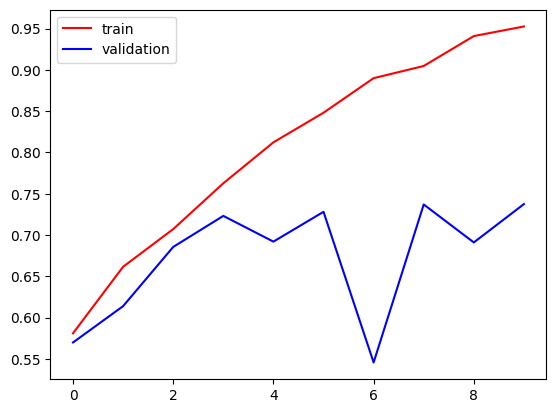

In [35]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

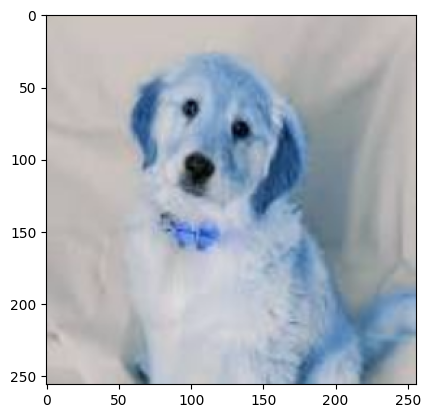

In [45]:
# testing on image of dog and cat
import cv2

img=cv2.imread('/content/download (1).jpg')
img1=cv2.resize(img,(256,256))

plt.imshow(img1)
plt.show()



In [46]:
test_img=img1.reshape((1,256,256,3))
model.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)